In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Práctica Módulo 3 — Feature Engineering con scikit-learn

**Erik Owen Castro Flores - A01800371**

**Caso:** Una universidad requiere un modelo predictivo para determinar si un estudiante **aprobará (`passed`)** un curso una semana antes del examen final, basándose en datos históricos.

Este notebook presenta el flujo de trabajo completo para la preparación de datos y construcción de un modelo base:
- **Parte 1:** Análisis exploratorio, detección de fuga de datos y justificación de ingeniería de características.
- **Parte 2:** Implementación de un `Pipeline` de scikit-learn que integra `ColumnTransformer` (imputación, escalado y encoding) y un clasificador.

## Parte 1: Analizar las características

### 1.1 Carga y vistazo general del dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('/content/drive/MyDrive/datasets/student_feature_engineering_dataset.csv')
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (120, 15)


,student_id,age,gender,program,enrollment_year,hours_studied,attendance,previous_grade,current_midterm,sleep_hours,commute_time,num_assignments_late,internet_access,final_grade,passed
0,S001,21,Male,IDM,2022,12.5,73.7,100.0,58.8,8.0,24,0,Yes,67.7,No
1,S002,24,Male,IDM,2025,11.9,88.1,88.7,58.1,8.7,24,2,Yes,68.6,No
2,S003,20,Female,ITC,2024,10.9,72.7,68.8,59.0,8.1,19,0,Yes,69.2,No
3,S004,21,Male,IRS,2022,13.4,93.0,55.6,50.1,6.8,5,2,Yes,72.4,Yes
4,S005,23,Male,IDM,2022,14.6,97.9,78.1,55.2,6.2,30,2,Yes,71.8,Yes


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            120 non-null    object 
 1   age                   120 non-null    int64  
 2   gender                120 non-null    object 
 3   program               120 non-null    object 
 4   enrollment_year       120 non-null    int64  
 5   hours_studied         120 non-null    float64
 6   attendance            120 non-null    float64
 7   previous_grade        120 non-null    float64
 8   current_midterm       120 non-null    float64
 9   sleep_hours           120 non-null    float64
 10  commute_time          120 non-null    int64  
 11  num_assignments_late  120 non-null    int64  
 12  internet_access       120 non-null    object 
 13  final_grade           120 non-null    float64
 14  passed                120 non-null    object 
dtypes: float64(6), int64(4)

### 1.2 Estadísticos descriptivos y variables categóricas

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,120.0,21.683333,2.173110,18.0,20.000,22.00,24.000,25.0
enrollment_year,120.0,2023.383333,1.124093,2022.0,2022.000,2023.00,2024.000,2025.0
hours_studied,120.0,10.344167,4.010298,2.0,7.100,10.80,12.700,25.0
attendance,120.0,82.492500,8.672318,49.6,76.325,82.45,88.300,100.0
previous_grade,120.0,77.862500,11.653961,52.7,69.250,77.50,85.825,100.0
current_midterm,120.0,50.979167,8.959347,35.0,44.700,50.80,57.125,74.1
sleep_hours,120.0,6.890000,1.163983,4.0,6.075,6.90,7.700,9.9
commute_time,120.0,34.508333,18.824709,5.0,23.250,34.00,47.000,86.0
num_assignments_late,120.0,1.433333,1.281631,0.0,0.000,1.00,2.000,6.0
final_grade,120.0,64.780833,9.497902,45.1,57.875,64.15,71.625,89.4


In [7]:
cat_cols = ['gender', 'program', 'internet_access', 'passed']
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- gender ---
gender
Female        60
Male          56
Non-binary     4
Name: count, dtype: int64

--- program ---
program
ITC    57
IDM    48
IRS    11
IBQ     4
Name: count, dtype: int64

--- internet_access ---
internet_access
Yes    111
No       9
Name: count, dtype: int64

--- passed ---
passed
No     81
Yes    39
Name: count, dtype: int64



**Notas**
- `gender` tiene 3 categorías (`Male`, `Female`, `Non-binary`), `program` tiene 4 (`ITC`, `IDM`, `IRS`, `IBQ`) e `internet_access` es binaria (`Yes`/`No`). Todas son de baja cardinalidad.
- El target `passed` está desbalanceado: 81 "No" vs 39 "Yes" (68% / 32%).
- `student_id` es un identificador de texto único por fila (`S001`, `S002`, ...): no aporta señal predictiva.


### 1.3 Detección de fuga de datos (data leakage): `final_grade`

El enunciado pide predecir `passed` una semana antes del examen final, es decir, sin conocer el resultado del examen final. Sin embargo, el dataset incluye `final_grade` (la calificación del examen final). Analizamos si `passed` se deriva directamente de `final_grade`:

In [ ]:
print(df.groupby('passed')['final_grade'].agg(['min', 'max', 'mean']))

# Probamos si un simple umbral sobre final_grade reproduce exactamente 'passed'
for thresh in [60, 65, 70, 75]:
    pred = np.where(df['final_grade'] >= thresh, 'Yes', 'No')
    acc = (pred == df['passed']).mean()
    print(f"Umbral final_grade >= {thresh}  ->  coincide con 'passed' en {acc:.1%} de los casos")


         min   max       mean
passed                       
No      45.1  69.8  59.607407
Yes     70.0  89.4  75.525641
Umbral final_grade >= 60  ->  coincide con 'passed' en 64.2% de los casos
Umbral final_grade >= 65  ->  coincide con 'passed' en 85.8% de los casos
Umbral final_grade >= 70  ->  coincide con 'passed' en 100.0% de los casos
Umbral final_grade >= 75  ->  coincide con 'passed' en 81.7% de los casos


**Conclusión:** `passed = 'Yes'` si `final_grade >= 70`. Es decir, `final_grade` determina exactamente el target (coincidencia del 100%). Usar `final_grade` como feature sería una fuga de datos en dos sentidos:
1. Es prácticamente el mismo target reformulado.
2. En el escenario real predecir antes del examen final esta variable no estaría disponible al momento de hacer la predicción.

Por lo tanto, `final_grade` debe eliminarse del conjunto de características.


### 1.4 Correlaciones entre variables numéricas y con el target

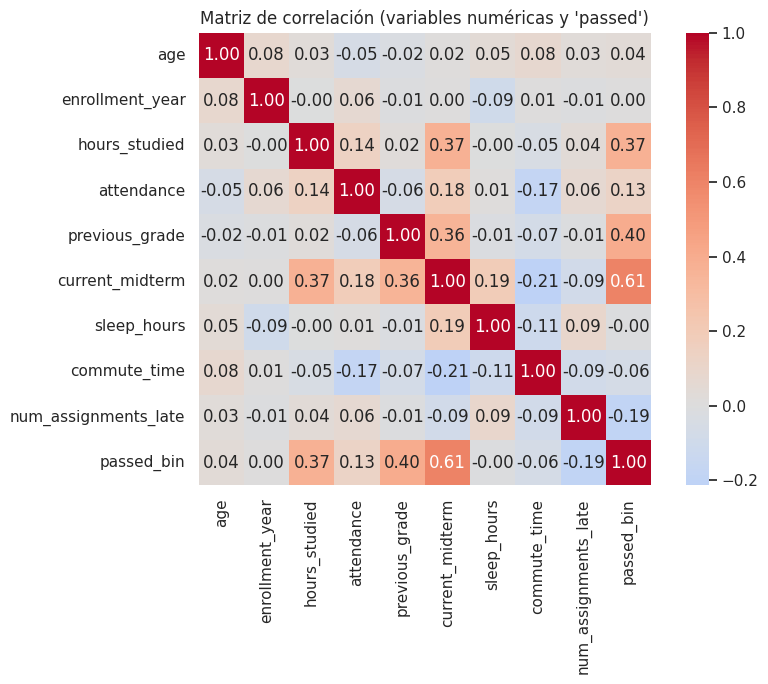

In [ ]:
df_corr = df.copy()
df_corr['passed_bin'] = (df_corr['passed'] == 'Yes').astype(int)

numeric_cols = ['age', 'enrollment_year', 'hours_studied', 'attendance', 'previous_grade',
                 'current_midterm', 'sleep_hours', 'commute_time', 'num_assignments_late']

corr_matrix = df_corr[numeric_cols + ['passed_bin']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación (variables numéricas y 'passed')")
plt.tight_layout()
plt.show()


**Lectura de la matriz:**
- `current_midterm` (0.60) y `previous_grade` (0.40) son, por mucho, las variables numéricas más correlacionadas con `passed`. Tiene sentido: son indicadores directos de desempeño académico.
- `hours_studied` (0.37) y `attendance` (0.13) muestran relación positiva moderada/baja.
- `num_assignments_late` (-0.19) tiene relación negativa: más tareas tardías, menor probabilidad de aprobar.
- `age`, `enrollment_year`, `sleep_hours` y `commute_time` muestran correlaciones individuales muy cercanas a cero con el target. Esto **no** significa que no tengan ningún valor (podrían aportar en combinación con otras variables), pero individualmente son señales débiles.


### 1.5 Distribuciones y valores atípicos de las variables numéricas

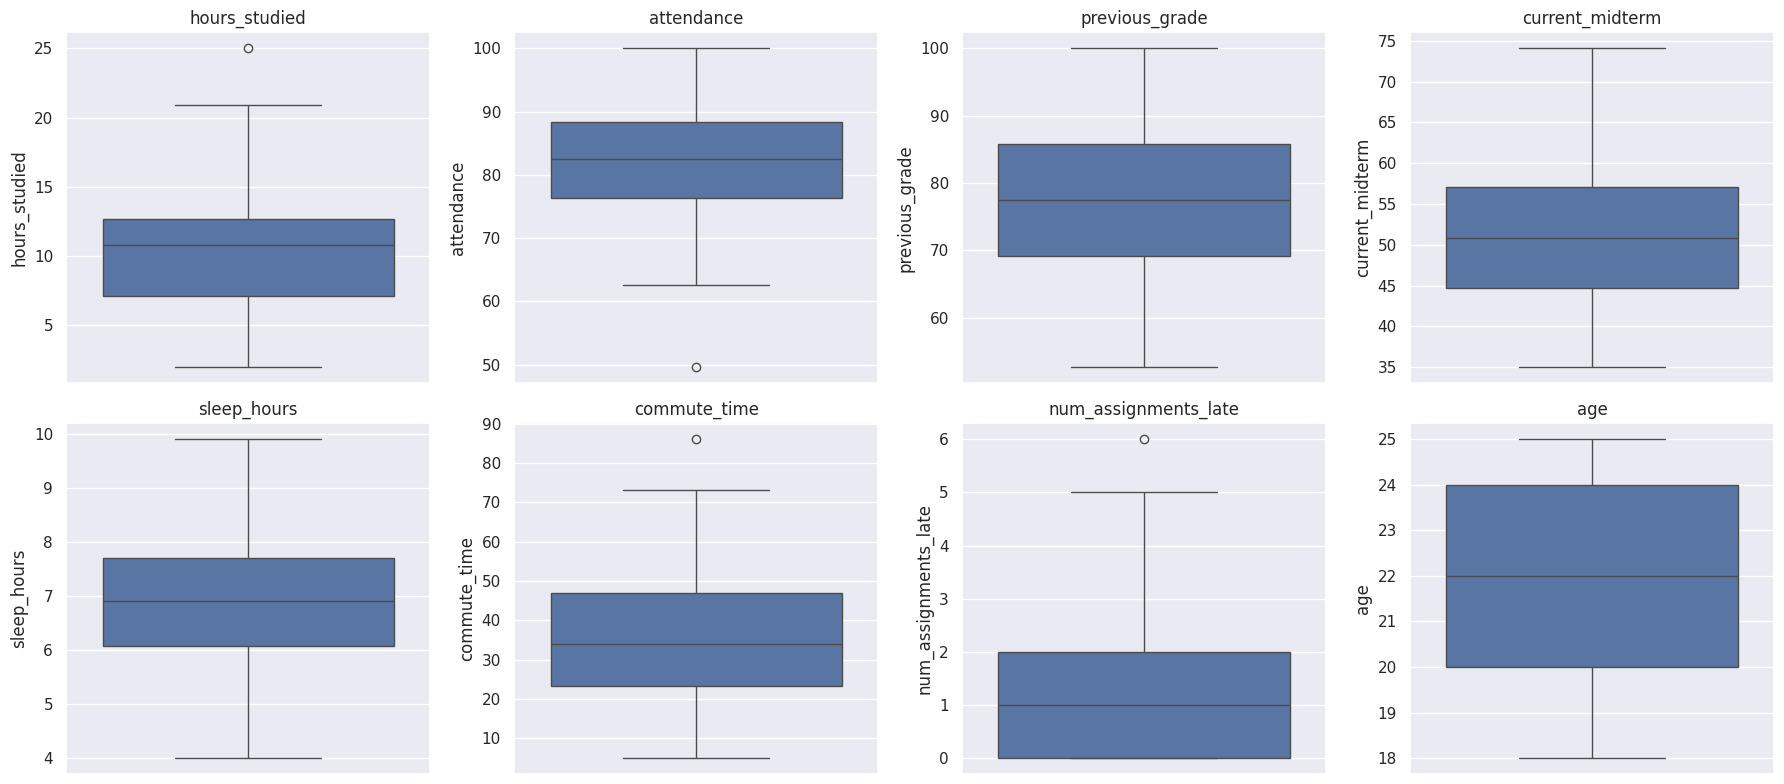

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
plot_cols = ['hours_studied', 'attendance', 'previous_grade', 'current_midterm',
             'sleep_hours', 'commute_time', 'num_assignments_late', 'age']
for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lo) | (series > hi)]

for col in ['hours_studied', 'attendance', 'sleep_hours', 'commute_time', 'num_assignments_late']:
    out = iqr_outliers(df[col])
    print(f"{col}: {len(out)} valor(es) atípico(s) -> {list(out.values)}")


hours_studied: 1 valor(es) atípico(s) -> [np.float64(25.0)]
attendance: 1 valor(es) atípico(s) -> [np.float64(49.6)]
sleep_hours: 0 valor(es) atípico(s) -> []
commute_time: 1 valor(es) atípico(s) -> [np.int64(86)]
num_assignments_late: 1 valor(es) atípico(s) -> [np.int64(6)]


Solo hay valores atípicos aislados (1 por variable, en un dataset de 120 filas) y no son valores imposibles o corruptos (p. ej. 25 horas de estudio/semana o 86 minutos de traslado son inusuales pero plausibles). No se eliminan filas por esto.

También se observa que las variables numéricas están en **escalas muy distintas** (`attendance` 0–100, `hours_studied` 2–25, `sleep_hours` 4–10, `commute_time` 5–86). Igual que en los ejemplos de `Age`/`Salary` y del dataset de pingüinos vistos en clase, esto se resuelve con `StandardScaler` dentro del `ColumnTransformer` (Parte 2). Por eso esta estandarización **no** se lista como una decisión de *"Transformar"* particular de cada variable — es un paso estándar del preprocesamiento numérico que se aplica por igual a todas las numéricas conservadas.


### 1.6 Variables categóricas vs. el target

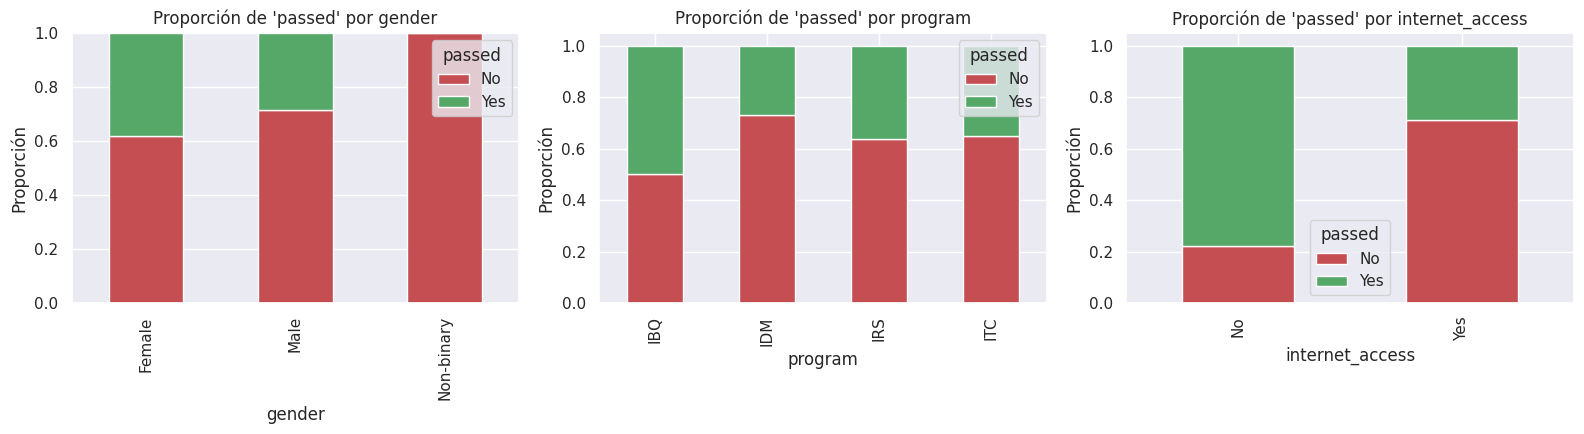

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['gender', 'program', 'internet_access']):
    ct = pd.crosstab(df[col], df['passed'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#C44E52', '#55A868'])
    ax.set_title(f"Proporción de 'passed' por {col}")
    ax.set_ylabel("Proporción")
    ax.legend(title='passed')
plt.tight_layout()
plt.show()


- `internet_access`: el grupo sin acceso a internet (`No`, solo 9 estudiantes) muestra una tasa de aprobación más alta que el grupo con acceso — probablemente ruido por el tamaño de muestra tan pequeño, pero se mantiene como variable binaria codificada.
- `gender` y `program`: hay diferencias moderadas en la tasa de aprobación entre grupos, especialmente en `Non-binary` (muestra pequeña, 4 casos) y `program == IBQ` (4 casos). Se mantienen codificadas, con la salvedad de que algunas categorías tienen muy pocos ejemplos.


### 1.7 Creación de nuevas características (Combinar)

Siguiendo el mismo patrón del ejemplo de *feature creation* del tutorial 07 (donde `petal_length` y `petal_width` se combinan en `petal_area` mediante una operación directa sobre el `DataFrame`), combinamos aquí dos parejas de variables con correlación individual débil respecto al target, pero con más sentido interpretadas **juntas**:

1. **`age` + `enrollment_year` → `age_at_enrollment`** (edad aproximada al momento de inscribirse al programa).
   `enrollment_year` por sí sola es solo una marca temporal (2022–2025) sin relación lineal clara con el desempeño; combinarla con `age` produce una variable con más significado.
2. **`sleep_hours` + `commute_time` → `net_rest_time`** (horas de sueño menos tiempo de traslado diario, en horas).
   Un traslado largo "resta" tiempo de descanso disponible; combinar ambas señales débiles en un solo indicador de "descanso neto" es más parsimonioso que dejarlas por separado.


In [ ]:
# Creación de features combinadas (mismo estilo que el ejemplo 'petal_area' del tutorial 07)
reference_year = df['enrollment_year'].max()  # año más reciente observado en el dataset

df['age_at_enrollment'] = df['age'] - (reference_year - df['enrollment_year'])
df['net_rest_time'] = df['sleep_hours'] - (df['commute_time'] / 60.0)

df[['age', 'enrollment_year', 'age_at_enrollment', 'sleep_hours', 'commute_time', 'net_rest_time']].head()


,age,enrollment_year,age_at_enrollment,sleep_hours,commute_time,net_rest_time
0,21,2022,18,8.0,24,7.600000
1,24,2025,24,8.7,24,8.300000
2,20,2024,19,8.1,19,7.783333
3,21,2022,18,6.8,5,6.716667
4,23,2022,20,6.2,30,5.700000


### 1.8 Tabla resumen — clasificación de cada característica

| # | Feature | Categoría | Justificación |
|---|---|---|---|
| 1 | `student_id` | **Eliminar** | Identificador único de texto sin poder predictivo; incluirlo arriesga que el modelo memorice filas en vez de generalizar. |
| 2 | `age` | **Combinar** (con `enrollment_year`) | Correlación individual con el target casi nula (0.04). Se combina con `enrollment_year` para formar `age_at_enrollment`, una variable más interpretable. |
| 3 | `gender` | **Transformar** | Categórica nominal de 3 clases → codificar con `OneHotEncoder`. |
| 4 | `program` | **Transformar** | Categórica nominal de 4 clases → `OneHotEncoder`. |
| 5 | `enrollment_year` | **Combinar** (con `age`) | El año calendario crudo no tiene una relación lineal natural con el desempeño; se usa junto con `age` para calcular `age_at_enrollment`. |
| 6 | `hours_studied` | **Mantener sin cambios** | Buen predictor individual (r = 0.37 con `passed`); numérica, sin datos faltantes, un único atípico moderado. Solo recibe el escalado estándar genérico. |
| 7 | `attendance` | **Mantener sin cambios** | Ya está en una escala interpretable (0–100%); correlación positiva con el target. |
| 8 | `previous_grade` | **Mantener sin cambios** | Segundo predictor más fuerte (r = 0.40); sin valores atípicos relevantes. |
| 9 | `current_midterm` | **Mantener sin cambios** | El predictor individual más fuerte (r = 0.60); variable clave a conservar tal cual. |
| 10 | `sleep_hours` | **Combinar** (con `commute_time`) | Correlación casi nula con el target de forma individual (-0.005); se combina con `commute_time` en `net_rest_time`. |
| 11 | `commute_time` | **Combinar** (con `sleep_hours`) | Correlación individual débil (-0.06); aporta más como parte de `net_rest_time` que sola. |
| 12 | `num_assignments_late` | **Mantener sin cambios** | Correlación negativa moderada y con sentido de negocio (-0.19); variable de conteo ya lista para el modelo. |
| 13 | `internet_access` | **Transformar** | Categórica binaria `Yes`/`No` → codificar con `OneHotEncoder`. |
| 14 | `final_grade` | **Eliminar** | **Fuga de datos**: define exactamente al target (`passed` = `final_grade >= 70` en el 100% de los casos) y no estaría disponible una semana antes del examen final. |

> **Nota sobre "Mantener sin cambios":** en el pipeline (Parte 2), a todas las variables numéricas de esta categoría igualmente se les aplica `StandardScaler` (y, por buena práctica, imputación), ya que es un paso estándar del preprocesamiento numérico — a diferencia de una codificación categórica o una combinación de columnas, que sí cambian el significado o la estructura de la información original.


## Parte 2: Implementación del pipeline

A continuación, se implementa el proceso de modelado siguiendo estas etapas:

1.  **Limpieza Inicial:** Eliminación de identificadores y variables que causan fuga de datos.
2.  **Feature Engineering:** Generación de las variables combinadas justificadas en el análisis previo.
3.  **División de Datos:** Separación en conjuntos de entrenamiento y prueba con estratificación debido al desbalance de clases.
4.  **Pipeline de Preprocesamiento:** Uso de `ColumnTransformer` para aplicar transformaciones específicas a columnas numéricas y categóricas.
5.  **Entrenamiento y Evaluación:** Ejecución del pipeline completo con un clasificador de Regresión Logística.

### 2.1 Preparación de columnas (aplicando las decisiones de la Parte 1)

In [ ]:
# Partimos del df ya con las columnas combinadas creadas en 1.7
df_model = df.drop(columns=[
    'student_id', 'final_grade',      # Eliminar
    'age', 'enrollment_year',         # ya combinadas en age_at_enrollment
    'sleep_hours', 'commute_time',    # ya combinadas en net_rest_time
])

df_model.head()


,gender,program,hours_studied,attendance,previous_grade,current_midterm,num_assignments_late,internet_access,passed,age_at_enrollment,net_rest_time
0,Male,IDM,12.5,73.7,100.0,58.8,0,Yes,No,18,7.600000
1,Male,IDM,11.9,88.1,88.7,58.1,2,Yes,No,24,8.300000
2,Female,ITC,10.9,72.7,68.8,59.0,0,Yes,No,19,7.783333
3,Male,IRS,13.4,93.0,55.6,50.1,2,Yes,Yes,18,6.716667
4,Male,IDM,14.6,97.9,78.1,55.2,2,Yes,Yes,20,5.700000


### 2.2 Separar `X` / `y` y hacer el `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['passed'])
y = df_model['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y  # stratify: 'passed' está desbalanceado (68% / 32%)
)

print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)


Entrenamiento: (90, 10)  | Prueba: (30, 10)


### 2.3 `ColumnTransformer`: preprocesamiento por grupo de columnas

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Variables que se MANTIENEN sin cambios + las 2 nuevas variables COMBINADAS
# (todas numéricas -> mismo tratamiento: imputar y luego escalar)
numeric_features = [
    'hours_studied', 'attendance', 'previous_grade', 'current_midterm',
    'num_assignments_late', 'age_at_enrollment', 'net_rest_time'
]

# Variables categóricas que se TRANSFORMAN (encoding)
categorical_features = ['gender', 'program', 'internet_access']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # por si en el futuro llegan datos faltantes
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 2.4 Pipeline completo (preprocesamiento + clasificador)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### 2.5 Entrenamiento y evaluación

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(f"Accuracy en el set de prueba: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))


Accuracy en el set de prueba: 0.87

              precision    recall  f1-score   support

          No       0.86      0.95      0.90        20
         Yes       0.88      0.70      0.78        10

    accuracy                           0.87        30
   macro avg       0.87      0.82      0.84        30
weighted avg       0.87      0.87      0.86        30



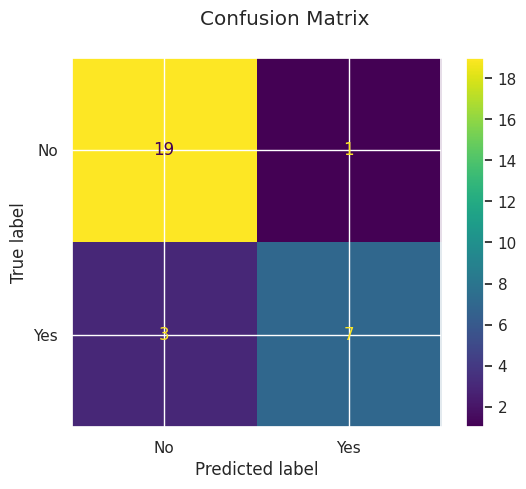

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay.from_estimator(model_pipeline, X_test, y_test)
cm.figure_.suptitle("Confusion Matrix")
plt.show()


**Conclusión de la implementación:**
El pipeline integra exitosamente todas las decisiones de ingeniería de características. Se han manejado variables numéricas mediante escalado estándar, variables categóricas mediante codificación One-Hot, y se han incluido las características generadas (`age_at_enrollment`, `net_rest_time`), logrando un flujo de trabajo reproducible y libre de fuga de datos.